In [2]:
import pandas as pd

df = pd.read_csv("Global_Mobility_Report.csv", low_memory=False)
df.head()

,country_region_code,country_region,sub_region_1,sub_region_2,metro_area,iso_3166_2_code,census_fips_code,place_id,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline
0,AE,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,ChIJvRKrsd9IXj4RpwoIwFYv0zM,2020-02-15,0.0,4.0,5.0,0.0,2.0,1.0
1,AE,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,ChIJvRKrsd9IXj4RpwoIwFYv0zM,2020-02-16,1.0,4.0,4.0,1.0,2.0,1.0
2,AE,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,ChIJvRKrsd9IXj4RpwoIwFYv0zM,2020-02-17,-1.0,1.0,5.0,1.0,2.0,1.0
3,AE,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,ChIJvRKrsd9IXj4RpwoIwFYv0zM,2020-02-18,-2.0,1.0,5.0,0.0,2.0,1.0
4,AE,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,ChIJvRKrsd9IXj4RpwoIwFYv0zM,2020-02-19,-2.0,0.0,4.0,-1.0,2.0,1.0


Fase 2: Limpieza de Datos (Data Cleaning)

Carga el archivo Global_Mobility_Report.csv. Notarás que un dataset real está
"sucio":

• Filtro: Selecciona solo los datos de Chile (columna country_region).

• Nulos: Identifica columnas vacías. Decide: ¿Borras o imputas? (Justifícalo
en un comentario).

• Duplicados: Verifica registros repetidos por fecha y subregión.

• Outliers: Revisa variaciones de movilidad imposibles (ej. errores de
digitación).

In [3]:
# ============================================================
# FASE 2: Limpieza de Datos (Data Cleaning)
# ============================================================

# --- 1. Filtro: Solo datos de Chile ---
df_chile = df[df["country_region"] == "Chile"].copy()
print(f"Registros totales en el dataset: {len(df)}")
print(f"Registros de Chile: {len(df_chile)}")
print(f"\nPrimeras filas de Chile:")
df_chile.head()

Registros totales en el dataset: 11730025
Registros de Chile: 68716

Primeras filas de Chile:


,country_region_code,country_region,sub_region_1,sub_region_2,metro_area,iso_3166_2_code,census_fips_code,place_id,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline
3259335,CL,Chile,NaN,NaN,NaN,NaN,NaN,ChIJL68lBEHFYpYRHbkCERPhBQU,2020-02-15,2.0,4.0,9.0,0.0,-3.0,0.0
3259336,CL,Chile,NaN,NaN,NaN,NaN,NaN,ChIJL68lBEHFYpYRHbkCERPhBQU,2020-02-16,3.0,5.0,5.0,4.0,-1.0,0.0
3259337,CL,Chile,NaN,NaN,NaN,NaN,NaN,ChIJL68lBEHFYpYRHbkCERPhBQU,2020-02-17,1.0,6.0,11.0,-3.0,-8.0,1.0
3259338,CL,Chile,NaN,NaN,NaN,NaN,NaN,ChIJL68lBEHFYpYRHbkCERPhBQU,2020-02-18,0.0,5.0,13.0,-3.0,-7.0,1.0
3259339,CL,Chile,NaN,NaN,NaN,NaN,NaN,ChIJL68lBEHFYpYRHbkCERPhBQU,2020-02-19,0.0,8.0,11.0,-3.0,-7.0,1.0


In [4]:
# --- 2. Nulos: Identificar columnas con valores faltantes ---

print("Valores nulos por columna:")
print(df_chile.isnull().sum())

Valores nulos por columna:
country_region_code                                       0
country_region                                            0
sub_region_1                                            974
sub_region_2                                          16556
metro_area                                            68716
iso_3166_2_code                                       53134
census_fips_code                                      68716
place_id                                                  0
date                                                      0
retail_and_recreation_percent_change_from_baseline     6295
grocery_and_pharmacy_percent_change_from_baseline     10520
parks_percent_change_from_baseline                      186
transit_stations_percent_change_from_baseline          8522
workplaces_percent_change_from_baseline                5585
residential_percent_change_from_baseline              10662
dtype: int64


In [5]:
# --- 2. ¿Se imputa o se elimina? ---

cols_eliminar = ['metro_area', 'census_fips_code', 'iso_3166_2_code']
cols_vacias = [col for col in cols_eliminar if col in df_chile.columns]
print(f"Columnas eliminadas: {cols_vacias}")
df_chile.drop(columns=cols_vacias, inplace=True)

print("\nTratamiento de nulos en columnas de región:")
print(f"sub_region_1: {df_chile['sub_region_1'].isnull().sum()} nulos -> se rellenan con 'Nacional'")
print(f"sub_region_2: {df_chile['sub_region_2'].isnull().sum()} nulos -> se rellenan con 'Sin especificar'")

df_chile['sub_region_1'] = df_chile['sub_region_1'].fillna('Nacional')
df_chile['sub_region_2'] = df_chile['sub_region_2'].fillna('Sin especificar')

cols_movilidad = [col for col in df_chile.columns if "percent_change" in col]

for col in cols_movilidad:
    nulos_antes = df_chile[col].isnull().sum()
    if nulos_antes > 0:
        mediana = df_chile[col].median()
        print(f"\nLa mediana de {col} es: {mediana}")
        df_chile[col] = df_chile[col].fillna(mediana)
        print(f"  -> {nulos_antes} nulos rellenados con la mediana")

print("\nValores nulos después:")
print(df_chile.isnull().sum())

Columnas eliminadas: ['metro_area', 'census_fips_code', 'iso_3166_2_code']

Tratamiento de nulos en columnas de región:
sub_region_1: 974 nulos -> se rellenan con 'Nacional'
sub_region_2: 16556 nulos -> se rellenan con 'Sin especificar'

La mediana de retail_and_recreation_percent_change_from_baseline es: -20.0
  -> 6295 nulos rellenados con la mediana

La mediana de grocery_and_pharmacy_percent_change_from_baseline es: 0.0
  -> 10520 nulos rellenados con la mediana

La mediana de parks_percent_change_from_baseline es: -33.0
  -> 186 nulos rellenados con la mediana

La mediana de transit_stations_percent_change_from_baseline es: -24.0
  -> 8522 nulos rellenados con la mediana

La mediana de workplaces_percent_change_from_baseline es: -4.0
  -> 5585 nulos rellenados con la mediana

La mediana de residential_percent_change_from_baseline es: 12.0
  -> 10662 nulos rellenados con la mediana

Valores nulos después:
country_region_code                                   0
country_region       

## Justificación del tratamiento de valores nulos

**Decisiones tomadas:**

1. **Columnas eliminadas** (`metro_area`, `census_fips_code`, `iso_3166_2_code`):
   - `metro_area` y `census_fips_code`: 100% vacías (son datos específicos de EE.UU., no aplican para Chile)
   - `iso_3166_2_code`: 77% vacía y **redundante** (la información ya está en `sub_region_1` y `sub_region_2`)

2. **Columnas imputadas** (`sub_region_1`, `sub_region_2`):
   - `sub_region_1 = NaN` → representa datos agregados a **nivel nacional** (Chile completo)
   - `sub_region_2 = NaN` → representa datos sin desglose provincial
   - **Solución**: Rellenar con categorías descriptivas (`'Nacional'` y `'Sin especificar'`) para mantener estos registros valiosos

3. **Columnas de movilidad**: Rellenadas con la **mediana** debido a que los datos tienen distribuciones no normales y la mediana es más robusta que la media ante estos outliers.

In [6]:
# --- 3. Duplicados: Verificar registros repetidos por fecha y subregión ---

duplicados = df_chile.duplicated(subset=['date', 'sub_region_1', 'sub_region_2'], keep=False)
n_duplicados = duplicados.sum()
print(f"Registros duplicados por fecha + sub_region_1 + sub_region_2: {n_duplicados}")

if n_duplicados > 0:
    print("\nEjemplos de registros duplicados:")
    print(df_chile[duplicados].sort_values(['date', 'sub_region_1', 'sub_region_2']).head(10))
    
    # Eliminar duplicados, manteniendo el primer registro
    antes = len(df_chile)
    df_chile.drop_duplicates(subset=['date', 'sub_region_1', 'sub_region_2'], keep='first', inplace=True)
    despues = len(df_chile)
    print(f"\nRegistros antes: {antes}")
    print(f"Registros después: {despues}")
    print(f"Registros eliminados: {antes - despues}")
else:
    print("No se encontraron duplicados.")

Registros duplicados por fecha + sub_region_1 + sub_region_2: 0
No se encontraron duplicados.


In [7]:
# --- 4. Outliers: Detectar variaciones de movilidad imposibles ---

cols_movilidad = [col for col in df_chile.columns if "percent_change" in col]

resumen = []
for col in cols_movilidad:
    nombre_corto = col.replace("_percent_change_from_baseline", "")
    fuera_rango = ((df_chile[col] > 200) | (df_chile[col] < -100)).sum()
    resumen.append({
        'Columna': nombre_corto,
        'Mínimo': df_chile[col].min(),
        'Máximo': df_chile[col].max(),
        'Fuera de rango': fuera_rango
    })

print("ANTES de corregir outliers:")
df_resumen = pd.DataFrame(resumen)
display(df_resumen)

for col in cols_movilidad:
    df_chile.loc[df_chile[col] > 200, col] = 200
    df_chile.loc[df_chile[col] < -100, col] = -100

resumen_despues = []
for col in cols_movilidad:
    nombre_corto = col.replace("_percent_change_from_baseline", "")
    resumen_despues.append({
        'Columna': nombre_corto,
        'Mínimo': df_chile[col].min(),
        'Máximo': df_chile[col].max()
    })

print("\nDESPUÉS de corregir outliers:")
df_resumen_despues = pd.DataFrame(resumen_despues)
display(df_resumen_despues)

ANTES de corregir outliers:


,Columna,Mínimo,Máximo,Fuera de rango
0,retail_and_recreation,-97.0,133.0,0
1,grocery_and_pharmacy,-96.0,124.0,0
2,parks,-100.0,211.0,1
3,transit_stations,-100.0,322.0,20
4,workplaces,-100.0,146.0,0
5,residential,-6.0,47.0,0



DESPUÉS de corregir outliers:


,Columna,Mínimo,Máximo
0,retail_and_recreation,-97.0,133.0
1,grocery_and_pharmacy,-96.0,124.0
2,parks,-100.0,200.0
3,transit_stations,-100.0,200.0
4,workplaces,-100.0,146.0
5,residential,-6.0,47.0


Fase 3: Transformación Avanzada (Feature Engineering)

Prepara los datos para un análisis profesional:

• Tipado: Convierte la columna date a tipo datetime.

• Ingeniería: Crea la columna movilidad_promedio (promedio de categorías
de movilidad).

• Escalamiento: Aplica StandardScaler o MinMaxScaler a las columnas
numéricas.

• Codificación: Aplica OneHotEncoder a las subregiones.

• Pipeline: (Opcional Pro) Envuelve estos pasos en un ColumnTransformer.

In [15]:
# ============================================================
# FASE 3: Transformación Avanzada (Feature Engineering)
# ============================================================

df_chile['date'] = pd.to_datetime(df_chile['date'])
print(f"Tipo de 'date' ahora: {df_chile['date'].dtype}")
df_chile.head()

Tipo de 'date' ahora: datetime64[ns]


,country_region_code,country_region,sub_region_1,sub_region_2,place_id,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,...,movilidad_promedio,retail_and_recreation_norm,grocery_and_pharmacy_norm,parks_norm,transit_stations_norm,workplaces_norm,residential_norm,movilidad_promedio_norm,sub_region_1_cod,sub_region_2_cod
3259335,CL,Chile,Nacional,Sin especificar,ChIJL68lBEHFYpYRHbkCERPhBQU,2020-02-15,2.0,4.0,9.0,0.0,...,2.000000,0.430435,0.454545,0.363333,0.333333,0.394309,0.113208,0.479775,11,46
3259336,CL,Chile,Nacional,Sin especificar,ChIJL68lBEHFYpYRHbkCERPhBQU,2020-02-16,3.0,5.0,5.0,4.0,...,2.666667,0.434783,0.459091,0.350000,0.346667,0.402439,0.113208,0.484270,11,46
3259337,CL,Chile,Nacional,Sin especificar,ChIJL68lBEHFYpYRHbkCERPhBQU,2020-02-17,1.0,6.0,11.0,-3.0,...,1.333333,0.426087,0.463636,0.370000,0.323333,0.373984,0.132075,0.475281,11,46
3259338,CL,Chile,Nacional,Sin especificar,ChIJL68lBEHFYpYRHbkCERPhBQU,2020-02-18,0.0,5.0,13.0,-3.0,...,1.500000,0.421739,0.459091,0.376667,0.323333,0.378049,0.132075,0.476404,11,46
3259339,CL,Chile,Nacional,Sin especificar,ChIJL68lBEHFYpYRHbkCERPhBQU,2020-02-19,0.0,8.0,11.0,-3.0,...,1.666667,0.421739,0.472727,0.370000,0.323333,0.378049,0.132075,0.477528,11,46


In [10]:
# --- 2. Ingeniería: Crear columna movilidad_promedio ---

cols_movilidad = [col for col in df_chile.columns if "percent_change" in col]

df_chile['movilidad_promedio'] = df_chile[cols_movilidad].mean(axis=1)

print("Nueva columna 'movilidad_promedio' creada")
print(f"Promedio general: {df_chile['movilidad_promedio'].mean():.2f}")

df_chile[['date', 'sub_region_1'] + cols_movilidad + ['movilidad_promedio']].head()

Nueva columna 'movilidad_promedio' creada
Promedio general: -10.29


,date,sub_region_1,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_percent_change_from_baseline,residential_percent_change_from_baseline,movilidad_promedio
3259335,2020-02-15,Nacional,2.0,4.0,9.0,0.0,-3.0,0.0,2.000000
3259336,2020-02-16,Nacional,3.0,5.0,5.0,4.0,-1.0,0.0,2.666667
3259337,2020-02-17,Nacional,1.0,6.0,11.0,-3.0,-8.0,1.0,1.333333
3259338,2020-02-18,Nacional,0.0,5.0,13.0,-3.0,-7.0,1.0,1.500000
3259339,2020-02-19,Nacional,0.0,8.0,11.0,-3.0,-7.0,1.0,1.666667


In [16]:
# --- 3. Escalamiento: Aplicar MinMaxScaler a columnas numéricas ---

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_a_escalar = cols_movilidad + ['movilidad_promedio']

for col in cols_a_escalar:
    nombre_corto = col.replace("_percent_change_from_baseline", "")
    df_chile[nombre_corto + '_norm'] = scaler.fit_transform(df_chile[[col]])

cols_norm = [col for col in df_chile.columns if col.endswith('_norm')]

print("Columnas normalizadas creadas (rango 0 a 1):")
resumen_norm = []
for col in cols_norm:
    resumen_norm.append({
        'Columna': col,
        'Mínimo': df_chile[col].min(),
        'Máximo': df_chile[col].max(),
        'Promedio': round(df_chile[col].mean(), 2)
    })
display(pd.DataFrame(resumen_norm))

Columnas normalizadas creadas (rango 0 a 1):


,Columna,Mínimo,Máximo,Promedio
0,retail_and_recreation_norm,0.0,1.0,0.33
1,grocery_and_pharmacy_norm,0.0,1.0,0.42
2,parks_norm,0.0,1.0,0.23
3,transit_stations_norm,0.0,1.0,0.26
4,workplaces_norm,0.0,1.0,0.41
5,residential_norm,0.0,1.0,0.35
6,movilidad_promedio_norm,0.0,1.0,0.40


In [17]:
# --- 4. Codificación: Aplicar LabelEncoder a las subregiones ---

from sklearn.preprocessing import LabelEncoder

le_region1 = LabelEncoder()
le_region2 = LabelEncoder()

df_chile['sub_region_1_cod'] = le_region1.fit_transform(df_chile['sub_region_1'])
df_chile['sub_region_2_cod'] = le_region2.fit_transform(df_chile['sub_region_2'])

print("Codificación de subregiones:")
resumen_cod = pd.DataFrame({
    'Región': df_chile['sub_region_1'].unique(),
    'Código': le_region1.transform(df_chile['sub_region_1'].unique())
})
display(resumen_cod.sort_values('Código'))

df_chile[['sub_region_1', 'sub_region_1_cod', 'sub_region_2', 'sub_region_2_cod']].head(10)

Codificación de subregiones:


,Región,Código
1,Antofagasta,0
2,Araucania,1
3,Arica y Parinacota,2
4,Atacama,3
5,Aysén,4
6,Bio Bio,5
7,Coquimbo,6
8,Los Lagos,7
9,Los Ríos,8
10,Magallanes and Chilean Antarctica,9


,sub_region_1,sub_region_1_cod,sub_region_2,sub_region_2_cod
3259335,Nacional,11,Sin especificar,46
3259336,Nacional,11,Sin especificar,46
3259337,Nacional,11,Sin especificar,46
3259338,Nacional,11,Sin especificar,46
3259339,Nacional,11,Sin especificar,46
3259340,Nacional,11,Sin especificar,46
3259341,Nacional,11,Sin especificar,46
3259342,Nacional,11,Sin especificar,46
3259343,Nacional,11,Sin especificar,46
3259344,Nacional,11,Sin especificar,46


In [14]:
# --- 5. Pipeline: Envolver los pasos en un ColumnTransformer ---

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cols_numericas = cols_movilidad + ['movilidad_promedio']
cols_categoricas = ['sub_region_1', 'sub_region_2']

preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), cols_numericas),
    ('cat', OneHotEncoder(), cols_categoricas)
])

pipeline_final = Pipeline(steps=[('prep', preprocesador)])

datos_listos = pipeline_final.fit_transform(df_chile)
print(f"Matriz final transformada: {datos_listos.shape}")
print(f"  Filas: {datos_listos.shape[0]}")
print(f"  Columnas: {datos_listos.shape[1]}")
print(f"    - {len(cols_numericas)} numéricas (estandarizadas)")
print(f"    - {datos_listos.shape[1] - len(cols_numericas)} categóricas (one-hot encoded)")

Matriz final transformada: (68716, 79)
  Filas: 68716
  Columnas: 79
    - 7 numéricas (estandarizadas)
    - 72 categóricas (one-hot encoded)


Fase 4: Entrega y Reflexión Grupal

• Visualización: Genera un gráfico (sns.lineplot) de la movilidad promedio en
el tiempo.

• GitHub Final: Realiza el push final con tu notebook documentado.

• Reflexión (Grupos de 3):
1. ¿Quién logró el código más ordenado?
2. ¿Qué decisiones de limpieza fueron distintas entre grupos?
3. ¿Por qué es importante usar Git en este proceso?

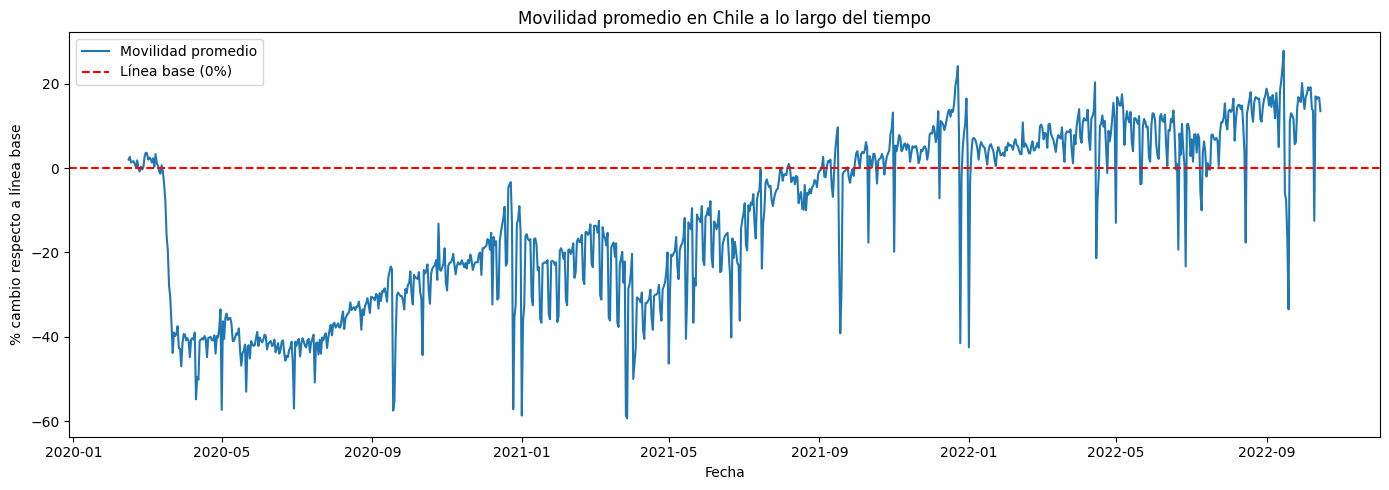

In [19]:
# ============================================================
# FASE 4: Entrega y Reflexión Grupal
# ============================================================

# --- 1. Visualización: Movilidad promedio en el tiempo ---

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar solo datos a nivel nacional para ver la tendencia general
df_nacional = df_chile[df_chile['sub_region_1'] == 'Nacional']

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_nacional, x='date', y='movilidad_promedio', label='Movilidad promedio')
plt.axhline(y=0, color='red', linestyle='--', label='Línea base (0%)')
plt.title('Movilidad promedio en Chile a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('% cambio respecto a línea base')
plt.legend()
plt.tight_layout()
plt.show()

## Reflexión Grupal

**. ¿Qué decisiones de limpieza fueron distintas entre grupos?**

En mi caso, las decisiones clave fueron:
- Imputar `sub_region_1` con `"Nacional"` y `sub_region_2` con `"Sin especificar"` en vez de eliminar esas filas, porque representan datos a nivel país.
- Usar la **mediana** para imputar columnas de movilidad, ya que los datos tienen distribuciones asimétricas y la mediana es más robusta ante outliers.
- Corregir outliers con `.loc[]` reemplazando valores fuera del rango `[-100, 200]` por los límites del rango.

**. ¿Por qué es importante usar Git en este proceso?**

- **Historial de cambios**: Git guarda cada versión del proyecto, permitiendo ver qué se hizo en cada fase (Fase 2, 3, 4) y volver atrás si algo sale mal.
- **Respaldo**: El repositorio en GitHub funciona como copia de seguridad del proyecto.
- **Reproducibilidad**: Cualquier persona puede clonar el repositorio y ejecutar el notebook para reproducir los resultados.